In [1]:
from langchain_community.tools import ArxivQueryRun,WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper,ArxivAPIWrapper

In [2]:
api_wrapper_arxiv=ArxivAPIWrapper(top_k_results=2,doc_content_chars_max=500)
arxiv=ArxivQueryRun(api_wrapper=api_wrapper_arxiv)
print(arxiv.name)

arxiv


In [4]:
arxiv.invoke("Attention is all you need")

'Published: 2021-05-06\nTitle: Do You Even Need Attention? A Stack of Feed-Forward Layers Does Surprisingly Well on ImageNet\nAuthors: Luke Melas-Kyriazi\nSummary: The strong performance of vision transformers on image classification and other vision tasks is often attributed to the design of their multi-head attention layers. However, the extent to which attention is responsible for this strong performance remains unclear. In this short report, we ask: is the attention layer even necessary? Specifi'

In [5]:
api_wrapper_wiki=WikipediaAPIWrapper(top_k_results=1,doc_content_chars_max=500)
wiki=WikipediaQueryRun(api_wrapper=api_wrapper_wiki)
wiki.name

'wikipedia'

In [6]:
wiki.invoke("What is machine learning")

'Page: Machine learning\nSummary: Machine learning (ML) is a field of study in artificial intelligence concerned with the development and study of statistical algorithms that can learn from  data and generalize to unseen data, and thus perform tasks without being explicitly programmed. Advances in the field of deep learning have allowed neural networks, a class of statistical algorithms, to surpass many previous machine learning approaches in performance.\nStatistics and mathematical optimisation m'

In [7]:
from dotenv import load_dotenv
load_dotenv()

import os

os.environ["TAVILY_API_KEY"]=os.getenv("TAVILY_API_KEY")
os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")



In [8]:
from langchain_tavily import TavilySearch

tavily = TavilySearch()

In [10]:
tavily.invoke("Provide me the recent AI news for June 25th 2026")

{'query': 'Provide me the recent AI news for June 25th 2026',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://www.linkedin.com/pulse/ai-news-day-25-june-2026-simran-sran-qrj9c',
   'title': 'AI News of the Day - 25 June 2026 - LinkedIn',
   'content': 'OpenAI designed its own AI chip. AI companies are trying to eliminate the common cold. OpenAI revealed Jalapeño, its first custom inference',
   'score': 0.90633047,
   'raw_content': None},
  {'url': 'https://www.himss.org',
   'title': 'HIMSS: Healthcare Information and Management Systems Society',
   'content': 'HIMSS has announced the 2026 AI Advisory Group, Boston June 25 - 26, 2026 The AI in Healthcare Forum brings together clinicians, executives, technologists,',
   'score': 0.8296166,
   'raw_content': None},
  {'url': 'https://www.theguardian.com/technology/artificialintelligenceai',
   'title': 'AI (artificial intelligence) | The Guardian',
   'content': 'OpenAI staggers AI model rele

In [11]:
tools=[arxiv,wiki,tavily]

In [21]:
from langchain_groq import ChatGroq

llm=ChatGroq(model="openai/gpt-oss-20b")

llm_with_tools=llm.bind_tools(tools)

In [13]:
from pprint import pprint
from langchain_core.messages import AIMessage, HumanMessage
llm_with_tools.invoke([HumanMessage(content=f"What is the recent AI News")])

AIMessage(content='', additional_kwargs={'reasoning_content': 'User asks: "What is the recent AI News". Likely wants recent AI news. Should browse via tavily_search. Use query "recent AI news".', 'tool_calls': [{'id': 'fc_31a89dd6-e079-4d0e-93ac-655f6fbd6055', 'function': {'arguments': '{"query":"recent AI news","search_depth":"basic","topic":"general"}', 'name': 'tavily_search'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 69, 'prompt_tokens': 450, 'total_tokens': 519, 'completion_time': 0.073574803, 'completion_tokens_details': {'reasoning_tokens': 33}, 'prompt_time': 0.02432373, 'prompt_tokens_details': None, 'queue_time': 0.278315051, 'total_time': 0.097898533}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_8b41efc9a3', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019f08ea-bd77-7900-a01b-a486fef40955-0', tool_calls=[{'name': 'tavily_search', 'args': {'query': '

In [14]:
llm_with_tools.invoke([HumanMessage(content=f"What is the recent AI News")]).tool_calls

[{'name': 'tavily_search',
  'args': {'query': 'recent AI news',
   'search_depth': 'advanced',
   'time_range': 'day',
   'topic': 'news'},
  'id': 'fc_69a65d9e-5d54-4b34-a09f-b952b210f2fa',
  'type': 'tool_call'}]

In [15]:
from typing_extensions import TypedDict
from langchain_core.messages import AnyMessage
from typing import Annotated
from langgraph.graph.message import add_messages
class State(TypedDict):
    messages:Annotated[list[AnyMessage],add_messages]

d:\agenticai\.venv\Lib\site-packages\langgraph\cache\base\__init__.py:8: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


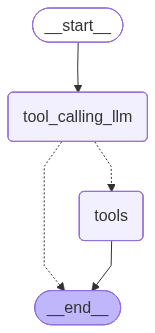

In [16]:
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

### Node definition
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tools.invoke(state["messages"])]}

# Build graph
builder = StateGraph(State)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))

builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    tools_condition,
)
builder.add_edge("tools", END)


graph = builder.compile()

# View
display(Image(graph.get_graph().draw_mermaid_png()))


In [17]:
messages=graph.invoke({"messages":HumanMessage(content="1706.03762")})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

1706.03762
================================== Ai Message ==================================
Tool Calls:
  arxiv (fc_13357a20-dbf3-4ad3-9f88-0900a83cd16c)
 Call ID: fc_13357a20-dbf3-4ad3-9f88-0900a83cd16c
  Args:
    query: 1706.03762
================================= Tool Message =================================
Name: arxiv

Published: 2023-08-02
Title: Attention Is All You Need
Authors: Ashish Vaswani, Noam Shazeer, Niki Parmar, Jakob Uszkoreit, Llion Jones, Aidan N. Gomez, Lukasz Kaiser, Illia Polosukhin
Summary: The dominant sequence transduction models are based on complex recurrent or convolutional neural networks in an encoder-decoder configuration. The best performing models also connect the encoder and decoder through an attention mechanism. We propose a new simple network architecture, the Transformer, base


In [20]:
messages=graph.invoke({"messages":HumanMessage(content="Provide me the top 10 recent AI news for  2026")})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

Provide me the top 10 recent AI news for  2026
================================== Ai Message ==================================
Tool Calls:
  tavily_search (fc_a5614419-005d-440b-9fda-ba80716c0b80)
 Call ID: fc_a5614419-005d-440b-9fda-ba80716c0b80
  Args:
    query: 2026 AI news top 10 recent
    search_depth: advanced
    topic: news
================================= Tool Message =================================
Name: tavily_search

{"query": "2026 AI news top 10 recent", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.modernghana.com/amp/videonews/670463", "title": "Future of AI: Self-improvement, risk and governance - Modern Ghana", "score": 0.81097376, "published_date": "Tue, 23 Jun 2026 06:40:00 GMT", "content": "HOME\n NEWS\n SPORTS\n SHOWBIZ\n AFRICA\n WORLD\n BUSINESS\n OPINIONS\n POLITICS\n LIFESTYLE\n HEALTH\n\nHome  › CGTN       23.06.2026\n\n# Futur

In [19]:
messages=graph.invoke({"messages":HumanMessage(content="What is machine learning")})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

What is machine learning
================================== Ai Message ==================================

**Machine learning (ML)** is a subfield of artificial intelligence that focuses on building systems that can learn patterns from data and improve their performance on a task without being explicitly programmed for every specific instance.

### Core ideas

| Concept | What it means | Typical example |
|---------|---------------|-----------------|
| **Learning from data** | The algorithm observes examples and adjusts its internal parameters to capture relationships. | A spam filter learns which words indicate spam. |
| **Generalization** | The model performs well on new, unseen data. | A handwriting recognizer correctly reads a freshly written digit. |
| **Model** | A mathematical function or structure that maps inputs to outputs. | A neural network, decision tree, support vector machine. |
| **Trainin